In [1]:
### ValDXer testing
import os
import os
os.environ["HDXER_PATH"] = "/home/alexi/Documents/HDXer"
from ValDX.ValidationDX import ValDXer
from ValDX.VDX_Settings import Settings

import pandas as pd
import MDAnalysis as mda
from MDAnalysis.coordinates.XTC import XTCWriter


settings = Settings()
settings.replicates = 1
settings.gamma_range = (2,6)
settings.train_frac = 0.5
settings.RW_exponent = [0]
settings.split_mode = 'R3'
settings.stride = 1000
# settings.HDXer_stride = 10000

settings.RW_do_reweighting = False
settings.RW_do_params = True
import pickle

# VDX = ValDXer(settings)
import cProfile
import pstats

/home/alexi/Documents/ValDX


/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# import subprocess
# from ValDX.helpful_funcs import conda_to_env_dict

# # Assuming settings.HDXer_env contains the name of your Conda environment
# env_path = conda_to_env_dict(settings.HDXer_env)

# command = "echo $HDXER_PATH"
# print("command:", command)

# # Run the command in the subprocess
# output = subprocess.run(command, shell=True, env=env_path, capture_output=True, text=True)

# # Capture and print the standard output (stdout)
# hdxer_path = output.stdout.strip()  # .strip() removes any trailing newline
# print("HDXER_PATH:", hdxer_path)


In [3]:
def pre_process_main_BPTI():
    # BPTI data
    expt_name = 'Experimental'
    test_name = "MD_Simulated"

    BPTI_dir = "/Users/alexi/Library/CloudStorage/OneDrive-Nexus365/Rotation_Projects/Rotation_3/Project/ValDX/raw_data/HDXer_tutorial/BPTI"
    BPTI_dir = "/home/alexi/Documents/ValDX/raw_data/HDXer_tutorial/BPTI"
    # BPTI_dir = "/home/alexi/Documents/ValDX/raw_data/HDXer_tutorial/BPTI"
    expt_dir = os.path.join(BPTI_dir, "BPTI_expt_data")

    os.listdir(expt_dir)

    segs_name = "BPTI_residue_segs.txt"
    segs_path = os.path.join(expt_dir, segs_name)

    hdx_name = "BPTI_expt_dfracs.dat"
    hdx_path = os.path.join(expt_dir, hdx_name)
    print(hdx_path)

    rates_name = "BPTI_Intrinsic_rates.dat"
    rates_path = os.path.join(expt_dir, rates_name)
    sim_name = 'BPTI_MD'

    sim_dir = os.path.join(BPTI_dir, "BPTI_simulations")

    os.listdir(sim_dir)

    md_reps = 1
    rep_dirs = ["Run_"+str(i+1) for i in range(md_reps)]

    top_name = "bpti_5pti_eq6_protonly.gro"

    top_path = os.path.join(sim_dir, rep_dirs[0], top_name)
    top_path = "/home/alexi/Documents/ValDX/raw_data/raw_pdbs/clean_pdbs/5PTI_chain_A.pdb"
    traj_name = "bpti_5pti_xtal.xtc"

    traj_paths = [os.path.join(sim_dir, rep_dir, traj_name) for rep_dir in rep_dirs]

    print(top_path)
    print(traj_paths)


    small_traj_name = traj_name.replace(".xtc","_small.xtc")
    small_traj_path = os.path.join(sim_dir, small_traj_name)

    u = mda.Universe(top_path)

    
        
    with XTCWriter(small_traj_path, n_atoms=u.atoms.n_atoms) as W:
        for ts in u.trajectory:
                W.write(u.atoms)
                W.write(u.atoms)

    top_path = "/home/alexi/Documents/ValDX/raw_data/HDXer_tutorial/BPTI/BPTI_simulations/SHAW/bpti.pdb"
    small_traj_path = "/home/alexi/Documents/ValDX/raw_data/HDXer_tutorial/BPTI/BPTI_simulations/SHAW/reduced_BPTI_SHAW_stride_1000.xtc"

    traj_paths = [small_traj_path]
    

    return hdx_path, segs_path, rates_path, top_path, traj_paths, sim_name, expt_name, test_name


In [4]:
hdx_path, segs_path, rates_path, top_path, traj_paths, sim_name, expt_name, test_name = pre_process_main_BPTI()

/home/alexi/Documents/ValDX/raw_data/HDXer_tutorial/BPTI/BPTI_expt_data/BPTI_expt_dfracs.dat
/home/alexi/Documents/ValDX/raw_data/raw_pdbs/clean_pdbs/5PTI_chain_A.pdb
['/home/alexi/Documents/ValDX/raw_data/HDXer_tutorial/BPTI/BPTI_simulations/Run_1/bpti_5pti_xtal.xtc']


/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/MDAnalysis/topology/PDBParser.py:345: UserWarning: Unknown element D found for some atoms. These have been given an empty element record. If needed they can be guessed using MDAnalysis.topology.guessers.
  warnings.warn(wmsg)
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: D
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/MDAnalysis/coordinates/XTC.py:105: UserWarning: Reader has no dt information, set to 1.0 ps
  time = ts.time


In [5]:
# def run_split_test(split_mode, name, system):

#     # settings.split_mode = 'R'
#     settings.split_mode = split_mode
#     settings.name = "_".join([name, split_mode, system])

#     VDX = ValDXer(settings)

#     VDX.load_HDX_data(HDX_path=hdx_path, SEG_path=segs_path, calc_name=expt_name)
#     VDX.load_intrinsic_rates(path=rates_path, calc_name=expt_name)

#     VDX.load_structures(top_path=top_path, traj_paths=traj_paths, calc_name=test_name)

#     run_outputs = VDX.run_VDX(calc_name=test_name, expt_name=expt_name)
#     analysis_dump, df, name = VDX.dump_analysis()
#     save_path = VDX.save_experiment()

#     return run_outputs, analysis_dump, df, name, save_path

In [6]:
def run_split_test_BPTI(split_mode, name, system):


    
    # settings.split_mode = 'R'
    settings.split_mode = split_mode
    settings.name = "_".join([name, split_mode, system])

    VDX = ValDXer(settings)

    VDX.load_HDX_data(HDX_path=hdx_path, SEG_path=segs_path, calc_name=expt_name)
    VDX.load_intrinsic_rates(path=rates_path, calc_name=expt_name)

    VDX.load_structures(top_path=top_path, traj_paths=traj_paths, calc_name=test_name)

    run_outputs = VDX.run_VDX(calc_name=test_name, expt_name=expt_name)
    analysis_dump, df, name = VDX.dump_analysis()
    save_path = VDX.save_experiment()

    return run_outputs, analysis_dump, df, name, save_path


splits = ['r', 's', 'R3', 'xR', 'Sp', 'SR']
split_names = ['naiverandom', 'NC_Termini', 'RedundantK', 'XtureK', 'pINspace', 'spaceK']
system = 'BPTITtut'

raw_run_outputs = {}
analysis_dumps = {}
analysis_df = pd.DataFrame()
names = []
save_paths = []

# initialise c profile
pr = cProfile.Profile()
pr.enable()


for split, split_name in zip(splits, split_names):
    run_outputs, analysis_dump, df, name, save_path = run_split_test_BPTI(split, split_name, system)
    raw_run_outputs[name] = run_outputs
    analysis_dumps.update(analysis_dump)
    analysis_df = pd.concat([analysis_df, df])
    names.append(name)
    save_paths.append(save_path)

# end c profile
pr.disable()
# create stats object
ps = pstats.Stats(pr)
# sort stats by cumulative time
ps.sort_stats('cumulative')


envs ['# conda environments:', '#', 'base                     /home/alexi/anaconda3', 'HDXER_ENV             *  /home/alexi/anaconda3/envs/HDXER_ENV', 'openfold_env             /home/alexi/anaconda3/envs/openfold_env', 'plumed-masterclass-2022     /home/alexi/anaconda3/envs/plumed-masterclass-2022', '                         /home/alexi/localcolabfold/colabfold-conda', '                         /home/alexi/localcolabfold/conda', '']
name base
name HDXER_ENV
Environment 'HDXER_ENV' found.
Path to 'HDXER_ENV' environment: /home/alexi/anaconda3/envs/HDXER_ENV
PATH /home/alexi/anaconda3/envs/HDXER_ENV:/home/alexi/anaconda3/envs/HDXER_ENV/bin:/home/alexi/anaconda3/condabin:/home/alexi/.vscode/cli/servers/Stable-903b1e9d8990623e3d7da1df3d33db3e42d80eda/server/bin/remote-cli:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin:/snap/bin
calc_hdx
/home/alexi/Documents/HDXer/HDXer/calc_hdx.py
Experiment name naiverandom_r_BPTITtut already exists. At

/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=o

/home/alexi/Documents/ValDX/data/naiverandom_r_BPTITtut64/train_MD_Simulated_1/reweighting_gamma_3x10^0/home/alexi/Documents/ValDX/data/naiverandom_r_BPTITtut64/train_MD_Simulated_1/reweighting_gamma_2x10^0/home/alexi/Documents/ValDX/data/naiverandom_r_BPTITtut64/train_MD_Simulated_1/reweighting_gamma_5x10^0/home/alexi/Documents/ValDX/data/naiverandom_r_BPTITtut64/train_MD_Simulated_1/reweighting_gamma_4x10^0



Contacts readContacts read

Hbonds readHbonds read

Segments and experimental dfracs readContacts readSegments and experimental dfracs read


Hbonds read
Segments and experimental dfracs readContacts read

Hbonds read
Segments and experimental dfracs read
Finished reweighting
[(array([0.00024242, 0.00024242, 0.00024242, ..., 0.00024242, 0.00024242,
       0.00024242]), 0.2531911367771917, 4.251422080239656), (array([0.00024242, 0.00024242, 0.00024242, ..., 0.00024242, 0.00024242,
       0.00024242]), 0.2531911367771917, 4.251422080239656), (array([0.00024242, 0.00024242, 0.0002

KeyboardInterrupt: 

In [ ]:
ps.print_stats()


         62873005 function calls (61606135 primitive calls) in 114.677 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000  114.687   57.344 /home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3472(run_code)
     14/2    0.000    0.000  114.687   57.344 {built-in method builtins.exec}
        1    0.000    0.000  114.687  114.687 /tmp/ipykernel_788353/476406561.py:38(<module>)
        6    0.000    0.000  114.684   19.114 /tmp/ipykernel_788353/476406561.py:1(run_split_test_BPTI)
        6    0.002    0.000  109.022   18.170 /home/alexi/Documents/ValDX/ValDX/ValidationDX.py:601(run_VDX)
       88    0.002    0.000   68.460    0.778 /home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/subprocess.py:452(run)
       88    0.001    0.000   67.804    0.771 /home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/subprocess.py:984(communicate)
       18    0.001    0.

In [ ]:
# def run_split_test_BPTI(split_mode, name, system):

    
#     # settings.split_mode = 'R'
#     settings.split_mode = split_mode
#     settings.name = "_".join([name, split_mode, system])

#     VDX = ValDXer(settings)

#     VDX.load_HDX_data(HDX_path=hdx_path, SEG_path=segs_path, calc_name=expt_name)
#     VDX.load_intrinsic_rates(path=rates_path, calc_name=expt_name)

#     VDX.load_structures(top_path=top_path, traj_paths=traj_paths, calc_name=test_name)

#     run_outputs = VDX.run_VDX(calc_name=test_name, expt_name=expt_name)
#     analysis_dump, df, name = VDX.dump_analysis()
#     save_path = VDX.save_experiment()

#     return run_outputs, analysis_dump, df, name, save_path


# splits = ['r', 's', 'R3', 'xR', 'Sp', 'SR']
# split_names = ['naiverandom', 'NC_Termini', 'RedundantK', 'XtureK', 'pINspace', 'spaceK']
# system = 'BPTITtut'

# raw_run_outputs = {}
# analysis_dumps = {}
# analysis_df = pd.DataFrame()
# names = []
# save_paths = []




# for split, split_name in zip(splits, split_names):
#     run_outputs, analysis_dump, df, name, save_path = run_split_test_BPTI(split, split_name, system)
#     raw_run_outputs[name] = run_outputs
#     analysis_dumps.update(analysis_dump)
#     analysis_df = pd.concat([analysis_df, df])
#     names.append(name)
#     save_paths.append(save_path)



/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/seaborn/axisgrid.py:723: UserWarning: Using the boxplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)


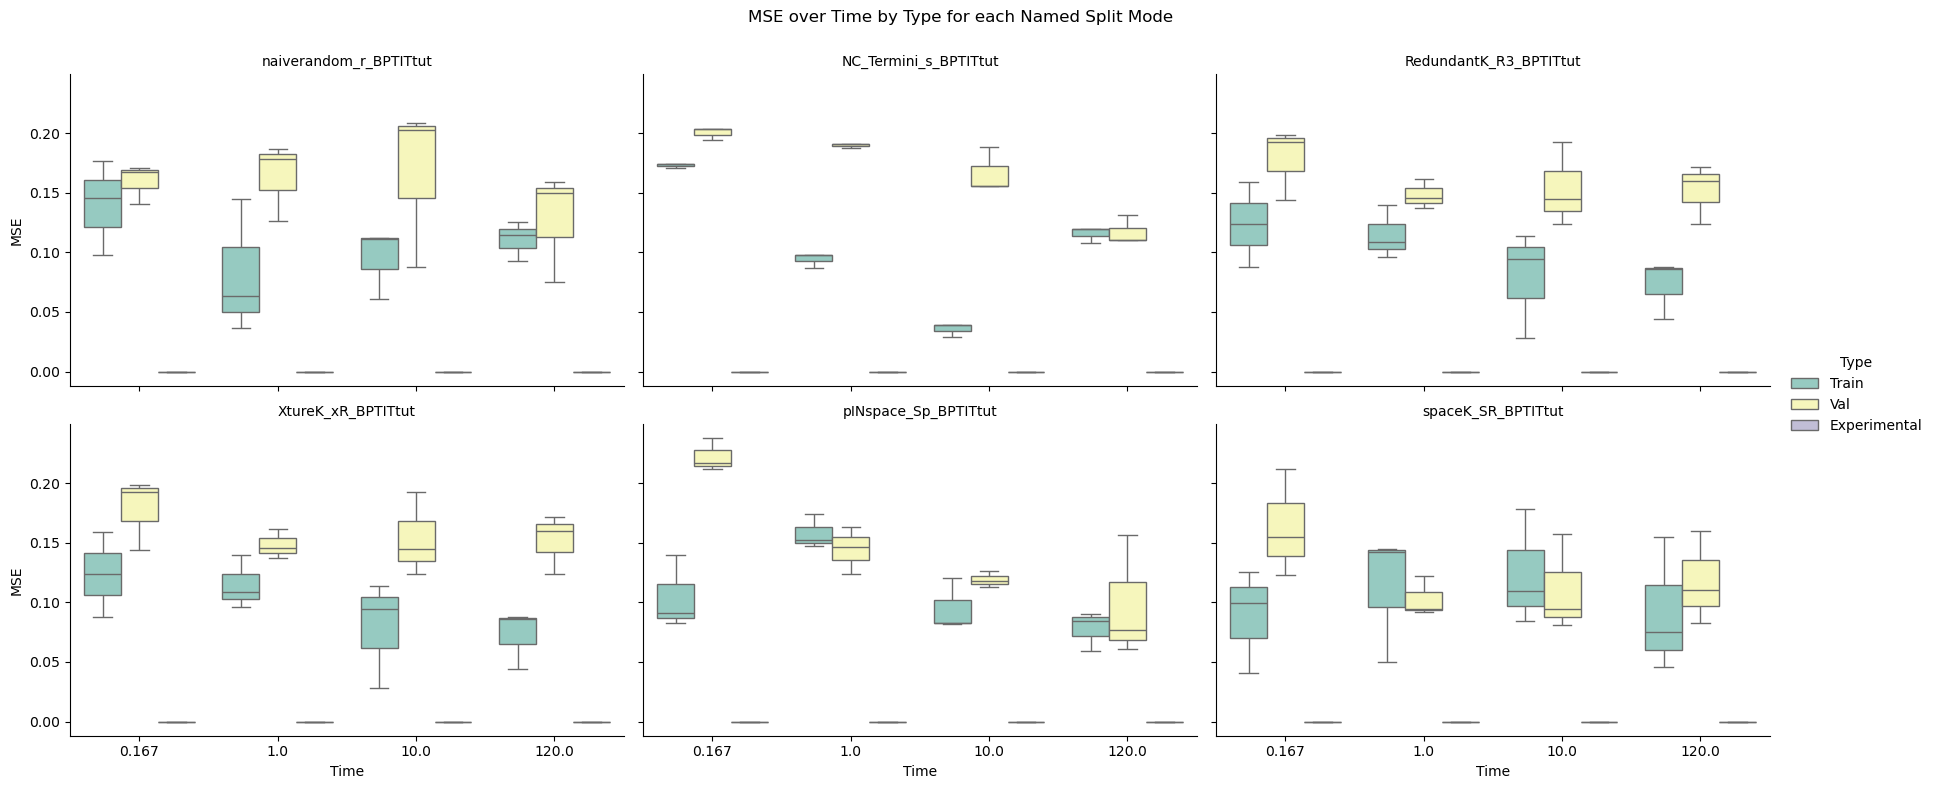

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
# Replace 'your_dataframe' with your actual DataFrame variable
df = analysis_df

# Create a FacetGrid, using 'name' for each subplot
g = sns.FacetGrid(df, col="name", col_wrap=3, height=4, aspect=1.5)
g.fig.suptitle('MSE over Time by Type for each Named Split Mode')

# Create boxplots
g = g.map(sns.boxplot, "time", "mse", "Type", palette="Set3")

# Adding some additional options for better visualization
g.add_legend(title='Type')
g.set_axis_labels("Time", "MSE")
g.set_titles("{col_name}")

# Adjust the arrangement of the plots
plt.subplots_adjust(top=0.9)

# Show plot
plt.show()


/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/seaborn/axisgrid.py:723: UserWarning: Using the boxplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)


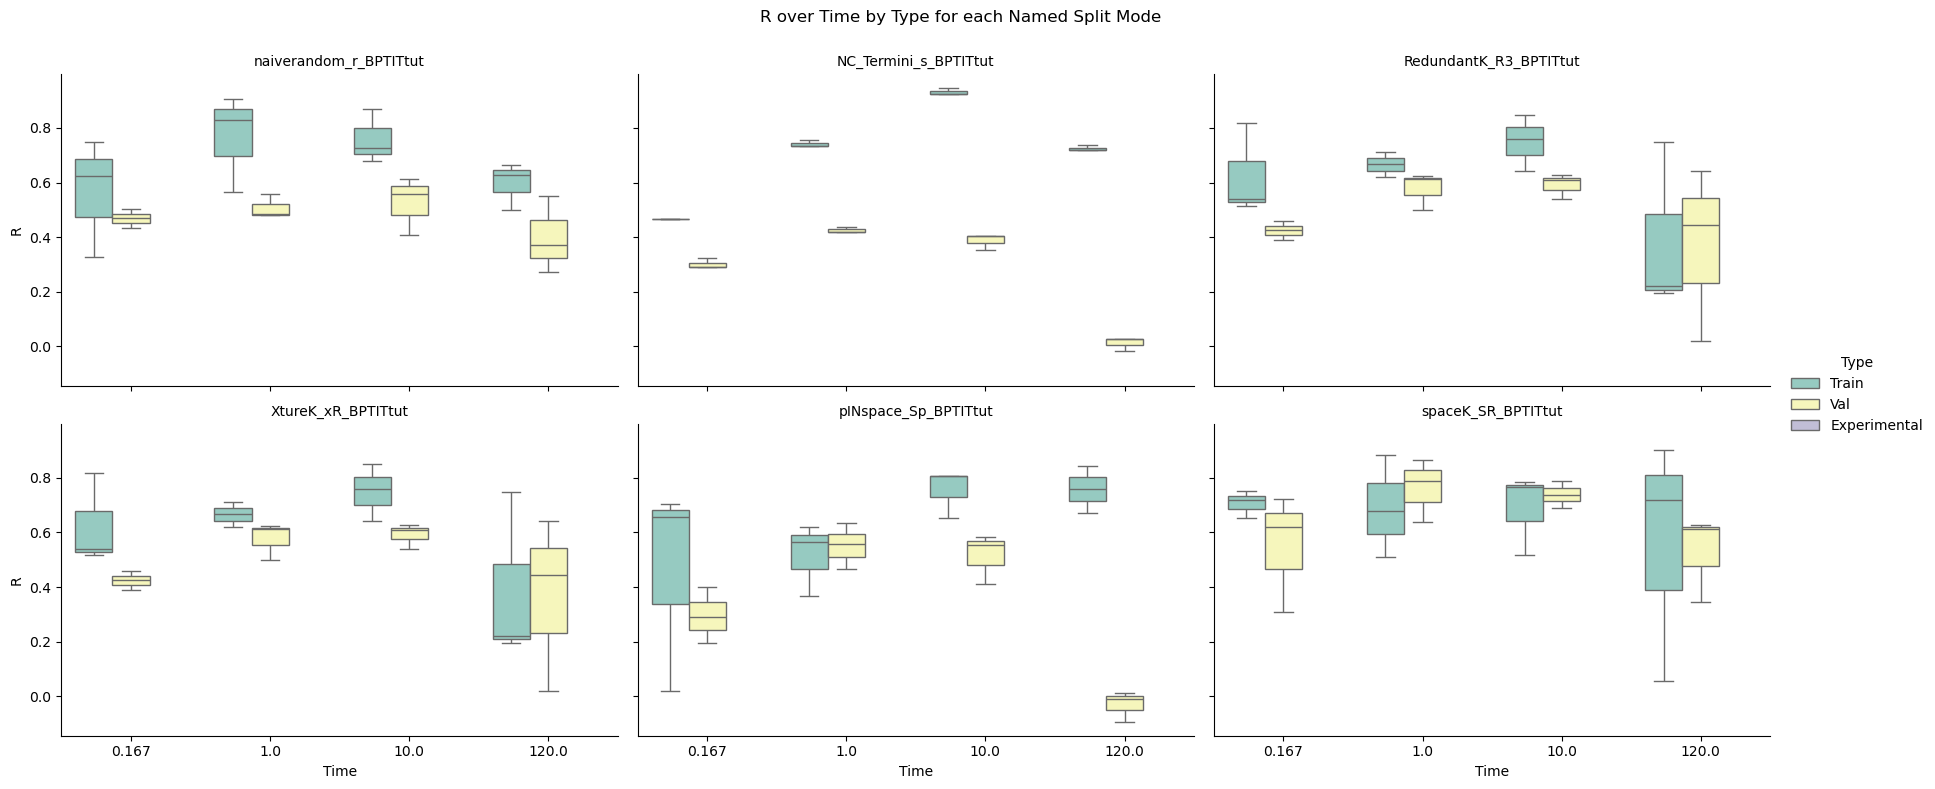

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
# Replace 'your_dataframe' with your actual DataFrame variable
df = analysis_df

# Create a FacetGrid, using 'name' for each subplot
g = sns.FacetGrid(df, col="name", col_wrap=3, height=4, aspect=1.5)
g.fig.suptitle('R over Time by Type for each Named Split Mode')

# Create boxplots
g = g.map(sns.boxplot, "time", "R", "Type", palette="Set3")

# Adding some additional options for better visualization
g.add_legend(title='Type')
g.set_axis_labels("Time", "R")
g.set_titles("{col_name}")

# Adjust the arrangement of the plots
plt.subplots_adjust(top=0.9)

# Show plot
plt.show()


                                                LogPf  \
0   [5.549539547084498, 6.936924433855622, 4.43963...   
1   [7.0, 8.75, 8.75, 7.0, 7.35, 5.6, 5.9499999999...   
2   [6.936924433855622, 6.936924433855622, 5.54953...   
3   [5.549539547084498, 6.936924433855622, 6.93692...   
4   [5.215937374971174, 5.67466912998046, 3.187517...   
..                                                ...   
7   [6.172118407285612, 7.715148009107015, 7.71514...   
8   [4.277777573262381, 4.54513867159128, 3.208333...   
9   [7.0, 8.75, 8.75, 7.0, 7.35, 5.6, 5.9499999999...   
10  [5.347221966577976, 6.68402745822247, 6.684027...   
11  [5.347221966577976, 6.68402745822247, 6.684027...   

                   calc_name  \
0       train_MD_Simulated_1   
1   no_weight_MD_Simulated_1   
2         val_MD_Simulated_1   
3        test_MD_Simulated_1   
4       train_MD_Simulated_2   
..                       ...   
7        test_MD_Simulated_2   
8       train_MD_Simulated_3   
9   no_weight_MD_Simulated_

ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

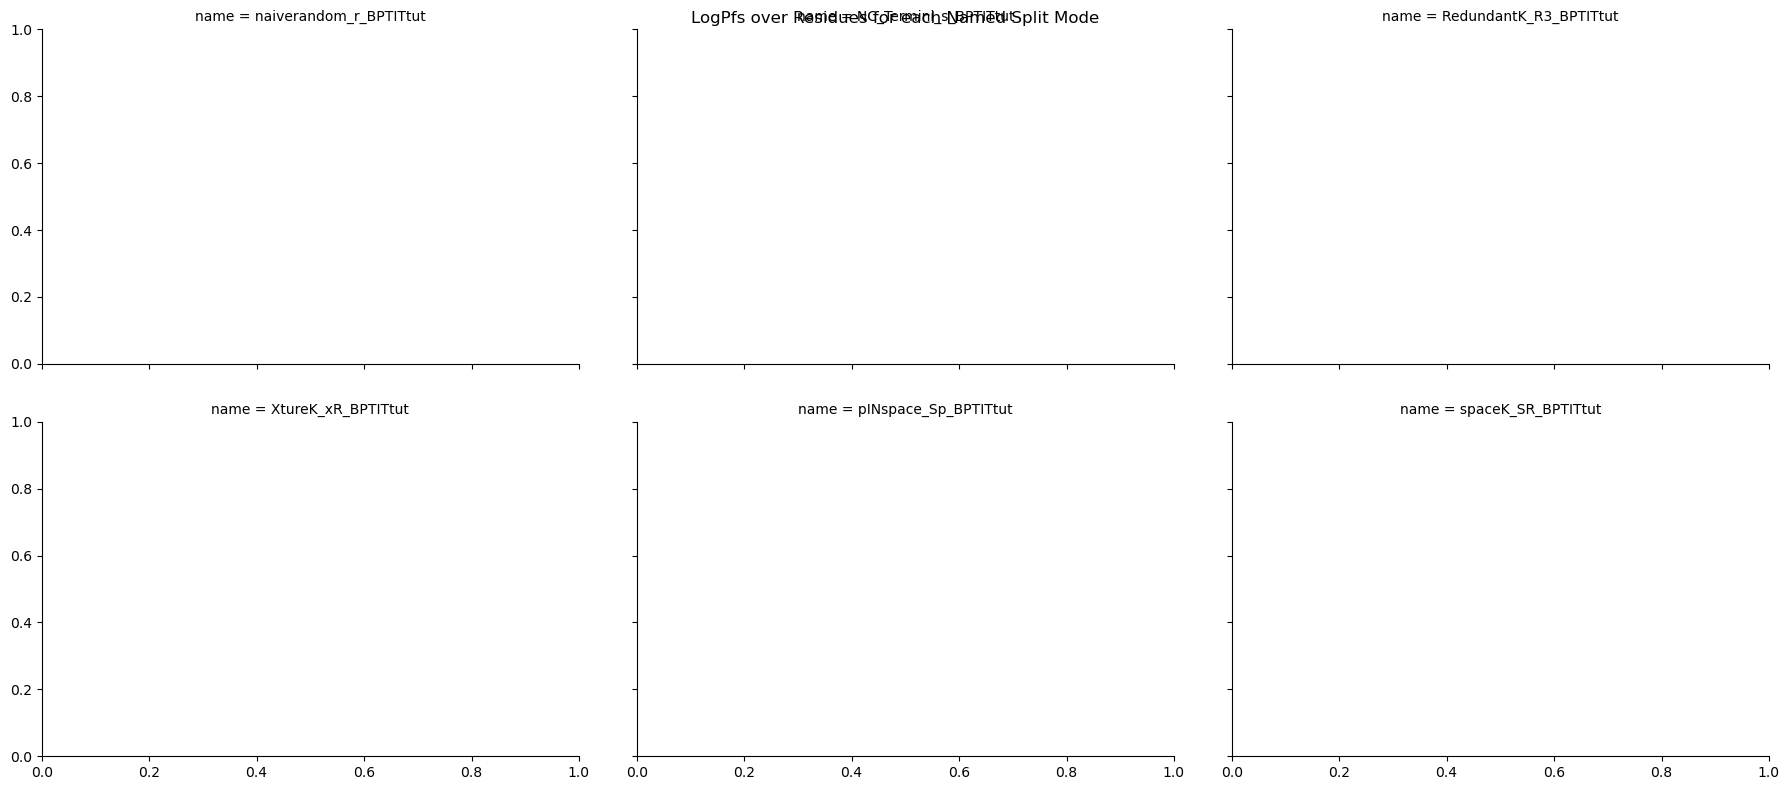

In [ ]:
# plot LogPfs by Residues colour by calc_name facet wrap by name
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
LogPfs = pd.concat([analysis_dumps[i]["LogPfs"] for i in names])

print(LogPfs)

LogPfs_df = LogPfs.explode(['LogPf','Residues'])


# Create a FacetGrid, using 'name' for each subplot
g = sns.FacetGrid(LogPfs_df, col="name", col_wrap=3, height=4, aspect=1.5)
g.fig.suptitle('LogPfs over Residues for each Named Split Mode')

# Create lineplots
g = g.map(sns.lineplot, "Residues", "LogPf", "calc_name", palette="Set2")

# Adding some additional options for better visualization
g.add_legend(title='calc_name')
g.set_axis_labels("Residues", "LogPf")
g.set_titles("{col_name}")

# Adjust the arrangement of the plots
plt.subplots_adjust(top=0.9)

# Show plot
plt.show()


In [ ]:
# plot BV distributions 
# print(analysis_dumps["AvsB_S"]["BV_constants"])

BV_constants = pd.concat([analysis_dumps[i]["BV_constants"] for i in names])
num_names = len(BV_constants)/len(names)
BV_constants["name"] = [i for i in names for j in range(int(num_names))]
print(BV_constants)

# Create a FacetGrid, using 'name' for each subplot - plot as scatter plot
g = sns.FacetGrid(BV_constants, col="name", col_wrap=3, height=4, aspect=1.5)
g.fig.suptitle('BV Constants over Residues for each Named Split Mode')

# Create lineplots
g = g.map(sns.scatterplot, "Bc", "Bh", "calc_name", palette="Set2")

# Adding some additional options for better visualization
g.add_legend(title='calc_name')
g.set_axis_labels("Residues", "BV")
g.set_titles("{col_name}")

# Adjust the arrangement of the plots
plt.subplots_adjust(top=0.9)

# Show plot
plt.show()


In [ ]:
# plot BV distributions 
bc, bh = 0.35, 2

BV_constants = pd.concat([analysis_dumps[i]["BV_constants"] for i in names])
num_names = len(BV_constants)/len(names)
BV_constants["name"] = [i for i in names for j in range(int(num_names))]
print(BV_constants)

# Create a FacetGrid with a single axis
g = sns.FacetGrid(BV_constants, height=4, aspect=1.5)
g.fig.suptitle('BV Constants over Residues for each Named Split Mode')

# Create scatter plot
g = g.map(sns.scatterplot, "Bc", "Bh", "name", palette="Set2", alpha=0.5)

# Adding dashed lines at bc and bh
plt.axhline(bh, color='grey', linestyle='dashed')
plt.axvline(bc, color='grey', linestyle='dashed')

# Adding some additional options for better visualization
g.add_legend(title='name')
g.set_axis_labels("Bc", "Bh")

# Adjust the arrangement of the plots
plt.subplots_adjust(top=0.9)

# Show plot
plt.show()


In [ ]:
# print(top_path)

In [ ]:
# pdb_test = mda.Universe(top_path)

# # write out as a pdb and add header
# pdb_test.atoms.write('test.pdb')
# with open('test.pdb', 'r') as original: data = original.read()
# with open('test.pdb', 'w') as modified: modified.write('HEADER    '+sim_name+'\n'+data)

